# Task 3: Event Impact Modeling

## Forecasting Financial Inclusion in Ethiopia

This notebook models preliminary relationships between major financial-
inclusion events and Ethiopia's Access and Usage indicators.

The analysis:

- connects event records to impact-link records;
- creates an event-indicator association matrix;
- represents event effects using direction, magnitude, and lag;
- compares selected estimates with observed historical changes;
- documents assumptions, uncertainty, and limitations.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ethiopia_fi_enriched.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {DATA_PATH}"
    )

print("Environment ready")

Project root: /Users/mac/Ethiopia-FI-Interim
Dataset path: /Users/mac/Ethiopia-FI-Interim/data/processed/ethiopia_fi_enriched.csv
Environment ready


In [2]:
df = pd.read_csv(DATA_PATH)

# Normalize column names.
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

# Normalize record types.
df["record_type_normalized"] = (
    df["record_type"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert numeric fields where available.
numeric_columns = [
    "value_numeric",
    "impact_magnitude",
    "lag_months",
    "confidence_score"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

# Convert possible date fields.
date_columns = [
    "observation_date",
    "event_date",
    "collection_date"
]

for column in date_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

print("Dataset shape:", df.shape)

print("\nRecord types:")
print(
    df["record_type_normalized"]
    .value_counts()
)

print("\nAvailable columns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (62, 36)

Record types:
record_type_normalized
observation    33
impact_link    15
event          11
target          3
Name: count, dtype: int64

Available columns:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'parent_id', 'record_type_normalized']


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,parent_id,record_type_normalized
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,Baseline year,NaN,NaN,observation
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,NaN,NaN,NaN,observation
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,NaN,NaN,NaN,observation
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,Gender disaggregated,NaN,NaN,observation
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,Gender disaggregated,NaN,NaN,observation


In [3]:
events = df[
    df["record_type_normalized"].eq("event")
].copy()

impact_links = df[
    df["record_type_normalized"].eq("impact_link")
].copy()

print("Event records:", len(events))
print("Impact-link records:", len(impact_links))

event_columns = [
    column for column in [
        "record_id",
        "indicator",
        "indicator_code",
        "category",
        "event_date",
        "observation_date",
        "source_name",
        "confidence"
    ]
    if column in events.columns
]

impact_columns = [
    column for column in [
        "record_id",
        "parent_id",
        "pillar",
        "related_indicator",
        "indicator_code",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "evidence_basis",
        "source_name",
        "confidence"
    ]
    if column in impact_links.columns
]

print("\nEvents")
display(events[event_columns])

print("\nImpact links")
display(impact_links[impact_columns])

Event records: 11
Impact-link records: 15

Events


,record_id,indicator,indicator_code,category,observation_date,source_name,confidence
33,EVT_0001,Telebirr Launch,EVT_TELEBIRR,product_launch,2021-05-17,Ethio Telecom,high
34,EVT_0002,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,market_entry,2022-08-01,News,high
35,EVT_0003,M-Pesa Ethiopia Launch,EVT_MPESA,product_launch,2023-08-01,Safaricom,high
36,EVT_0004,Fayda Digital ID Program Rollout,EVT_FAYDA,infrastructure,2024-01-01,NIDP,high
37,EVT_0005,Foreign Exchange Liberalization,EVT_FX_REFORM,policy,2024-07-29,NBE,high
38,EVT_0006,P2P Transaction Count Surpasses ATM,EVT_CROSSOVER,milestone,2024-10-01,EthSwitch,high
39,EVT_0007,M-Pesa EthSwitch Integration,EVT_MPESA_INTEROP,partnership,2025-10-27,EthSwitch,high
40,EVT_0008,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,infrastructure,2025-12-18,NBE/EthSwitch,high
41,EVT_0009,NFIS-II Strategy Launch,EVT_NFIS2,policy,2021-09-01,NBE,high
42,EVT_0010,Safaricom Ethiopia Price Increase,EVT_SAFCOM_PRICE,pricing,2025-12-15,News,high



Impact links


,record_id,parent_id,pillar,related_indicator,indicator_code,impact_direction,impact_magnitude,lag_months,evidence_basis,source_name,confidence
43,IMP_0001,EVT_0001,ACCESS,ACC_OWNERSHIP,NaN,increase,NaN,12.0,literature,NaN,medium
44,IMP_0002,EVT_0001,USAGE,USG_TELEBIRR_USERS,NaN,increase,NaN,3.0,empirical,NaN,high
45,IMP_0003,EVT_0001,USAGE,USG_P2P_COUNT,NaN,increase,NaN,6.0,empirical,NaN,medium
46,IMP_0004,EVT_0002,ACCESS,ACC_4G_COV,NaN,increase,NaN,12.0,empirical,NaN,medium
47,IMP_0005,EVT_0002,AFFORDABILITY,AFF_DATA_INCOME,NaN,decrease,NaN,12.0,literature,NaN,medium
48,IMP_0006,EVT_0003,USAGE,USG_MPESA_USERS,NaN,increase,NaN,3.0,empirical,NaN,high
49,IMP_0007,EVT_0003,ACCESS,ACC_MM_ACCOUNT,NaN,increase,NaN,6.0,theoretical,NaN,medium
50,IMP_0008,EVT_0004,ACCESS,ACC_OWNERSHIP,NaN,increase,NaN,24.0,literature,NaN,medium
51,IMP_0009,EVT_0004,GENDER,GEN_GAP_ACC,NaN,decrease,NaN,24.0,literature,NaN,medium
52,IMP_0010,EVT_0005,AFFORDABILITY,AFF_DATA_INCOME,NaN,increase,NaN,3.0,empirical,NaN,high


In [4]:
# Resolve the best available event-name column.
event_name_candidates = [
    "indicator",
    "event_name",
    "indicator_name",
    "description",
    "indicator_code",
    "record_id"
]

event_name_column = next(
    (
        column
        for column in event_name_candidates
        if column in events.columns
    ),
    None
)

if event_name_column is None:
    raise KeyError(
        "No event-name column could be identified."
    )

events["event_name_resolved"] = (
    events[event_name_column]
    .fillna("Unnamed event")
    .astype(str)
)

# Resolve event dates from any usable date column.
events["event_date_resolved"] = pd.NaT

for column in [
    "event_date",
    "observation_date",
    "date"
]:
    if column in events.columns:
        parsed = pd.to_datetime(
            events[column],
            errors="coerce"
        )

        events["event_date_resolved"] = (
            events["event_date_resolved"]
            .fillna(parsed)
        )

resolved_event_columns = [
    column for column in [
        "record_id",
        "event_name_resolved",
        "category",
        "event_date_resolved",
        "source_name",
        "confidence"
    ]
    if column in events.columns
]

events = events.sort_values(
    "event_date_resolved",
    na_position="last"
)

display(events[resolved_event_columns])

,record_id,event_name_resolved,category,event_date_resolved,source_name,confidence
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom,high
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01,NBE,high
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,News,high
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01,Safaricom,high
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,NIDP,high
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29,NBE,high
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01,EthSwitch,high
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27,EthSwitch,high
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,2025-12-15,News,high
40,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,2025-12-18,NBE/EthSwitch,high


In [5]:
event_lookup_columns = [
    column for column in [
        "record_id",
        "event_name_resolved",
        "event_date_resolved",
        "category",
        "source_name",
        "confidence"
    ]
    if column in events.columns
]

event_lookup = events[
    event_lookup_columns
].copy()

event_lookup = event_lookup.rename(
    columns={
        "record_id": "event_record_id",
        "source_name": "event_source_name",
        "confidence": "event_confidence"
    }
)

impact_event_model = impact_links.merge(
    event_lookup,
    left_on="parent_id",
    right_on="event_record_id",
    how="left",
    validate="many_to_one"
)

print(
    "Impact links successfully matched to events:",
    impact_event_model["event_record_id"].notna().sum(),
    "of",
    len(impact_event_model)
)

unmatched = impact_event_model[
    impact_event_model["event_record_id"].isna()
]

if not unmatched.empty:
    print("\nUnmatched parent IDs:")
    display(
        unmatched[
            [
                column
                for column in [
                    "record_id",
                    "parent_id",
                    "related_indicator"
                ]
                if column in unmatched.columns
            ]
        ]
    )

summary_columns = [
    column for column in [
        "event_name_resolved",
        "event_date_resolved",
        "category",
        "pillar",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "evidence_basis",
        "confidence"
    ]
    if column in impact_event_model.columns
]

display(
    impact_event_model[summary_columns]
    .sort_values(
        [
            column
            for column in [
                "event_date_resolved",
                "related_indicator"
            ]
            if column in impact_event_model.columns
        ]
    )
)

Impact links successfully matched to events: 15 of 15


,event_name_resolved,event_date_resolved,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,confidence
0,Telebirr Launch,2021-05-17,ACCESS,ACC_OWNERSHIP,increase,NaN,12.0,literature,medium
2,Telebirr Launch,2021-05-17,USAGE,USG_P2P_COUNT,increase,NaN,6.0,empirical,medium
1,Telebirr Launch,2021-05-17,USAGE,USG_TELEBIRR_USERS,increase,NaN,3.0,empirical,high
3,Safaricom Ethiopia Commercial Launch,2022-08-01,ACCESS,ACC_4G_COV,increase,NaN,12.0,empirical,medium
4,Safaricom Ethiopia Commercial Launch,2022-08-01,AFFORDABILITY,AFF_DATA_INCOME,decrease,NaN,12.0,literature,medium
6,M-Pesa Ethiopia Launch,2023-08-01,ACCESS,ACC_MM_ACCOUNT,increase,NaN,6.0,theoretical,medium
5,M-Pesa Ethiopia Launch,2023-08-01,USAGE,USG_MPESA_USERS,increase,NaN,3.0,empirical,high
7,Fayda Digital ID Program Rollout,2024-01-01,ACCESS,ACC_OWNERSHIP,increase,NaN,24.0,literature,medium
8,Fayda Digital ID Program Rollout,2024-01-01,GENDER,GEN_GAP_ACC,decrease,NaN,24.0,literature,medium
9,Foreign Exchange Liberalization,2024-07-29,AFFORDABILITY,AFF_DATA_INCOME,increase,NaN,3.0,empirical,high


In [6]:
# Restore original categorical impact values from the saved dataset.

raw_df = pd.read_csv(DATA_PATH)

raw_df.columns = (
    raw_df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

raw_df["record_type_normalized"] = (
    raw_df["record_type"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

raw_impact_links = raw_df[
    raw_df["record_type_normalized"].eq("impact_link")
].copy()

fields_to_restore = [
    "impact_direction",
    "impact_magnitude",
    "evidence_basis",
    "confidence",
    "lag_months"
]

available_restore_fields = [
    field
    for field in fields_to_restore
    if field in raw_impact_links.columns
]

restore_table = raw_impact_links[
    ["record_id"] + available_restore_fields
].copy()

restore_table = restore_table.rename(
    columns={
        field: f"{field}_original"
        for field in available_restore_fields
    }
)

impact_event_model = impact_event_model.merge(
    restore_table,
    on="record_id",
    how="left",
    validate="one_to_one"
)

for field in available_restore_fields:
    original_field = f"{field}_original"

    impact_event_model[field] = (
        impact_event_model[original_field]
        .combine_first(
            impact_event_model.get(
                field,
                pd.Series(index=impact_event_model.index, dtype="object")
            )
        )
    )

    impact_event_model = impact_event_model.drop(
        columns=[original_field]
    )

# Normalize categorical text.
for field in [
    "impact_direction",
    "impact_magnitude",
    "evidence_basis",
    "confidence"
]:
    if field in impact_event_model.columns:
        impact_event_model[field] = (
            impact_event_model[field]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

impact_event_model["lag_months"] = pd.to_numeric(
    impact_event_model["lag_months"],
    errors="coerce"
).fillna(0)

display(
    impact_event_model[
        [
            column
            for column in [
                "event_name_resolved",
                "related_indicator",
                "impact_direction",
                "impact_magnitude",
                "lag_months",
                "evidence_basis",
                "confidence"
            ]
            if column in impact_event_model.columns
        ]
    ]
)

,event_name_resolved,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,confidence
0,Telebirr Launch,ACC_OWNERSHIP,increase,high,12.0,literature,medium
1,Telebirr Launch,USG_TELEBIRR_USERS,increase,high,3.0,empirical,high
2,Telebirr Launch,USG_P2P_COUNT,increase,high,6.0,empirical,medium
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,medium,12.0,empirical,medium
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,medium,12.0,literature,medium
5,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,3.0,empirical,high
6,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,medium,6.0,theoretical,medium
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,medium,24.0,literature,medium
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,decrease,medium,24.0,literature,medium
9,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,high,3.0,empirical,high


In [7]:
# Convert qualitative impact-link information into standardized scores.
#
# Score interpretation:
#   Positive score = expected increase in the indicator
#   Negative score = expected decrease in the indicator
#   Larger absolute values = stronger expected association
#
# These scores are relative association strengths, not percentage points.

direction_map = {
    "increase": 1.0,
    "positive": 1.0,
    "decrease": -1.0,
    "negative": -1.0,
    "stabilize": 0.5,
    "stabilise": 0.5,
    "mixed": 0.0,
    "neutral": 0.0,
    "unclear": 0.0,
    "": 0.0
}

magnitude_map = {
    "high": 3.0,
    "medium": 2.0,
    "moderate": 2.0,
    "low": 1.0,
    "negligible": 0.25,
    "": 1.0
}

evidence_weight_map = {
    "empirical": 1.00,
    "literature": 0.85,
    "theoretical": 0.65,
    "expert": 0.60,
    "": 0.50
}

confidence_weight_map = {
    "high": 1.00,
    "medium": 0.75,
    "low": 0.50,
    "": 0.50
}

impact_event_model["direction_sign"] = (
    impact_event_model["impact_direction"]
    .map(direction_map)
    .fillna(0.0)
)

impact_event_model["magnitude_weight"] = (
    impact_event_model["impact_magnitude"]
    .map(magnitude_map)
    .fillna(1.0)
)

impact_event_model["evidence_weight"] = (
    impact_event_model["evidence_basis"]
    .map(evidence_weight_map)
    .fillna(0.50)
)

impact_event_model["confidence_weight"] = (
    impact_event_model["confidence"]
    .map(confidence_weight_map)
    .fillna(0.50)
)

# Base score before evidence and confidence adjustments.
impact_event_model["base_effect_score"] = (
    impact_event_model["direction_sign"]
    * impact_event_model["magnitude_weight"]
)

# Final relative association score.
impact_event_model["effect_score"] = (
    impact_event_model["base_effect_score"]
    * impact_event_model["evidence_weight"]
    * impact_event_model["confidence_weight"]
)

# A near-term score discounts effects that require a longer lag.
impact_event_model["near_term_effect_score"] = (
    impact_event_model["effect_score"]
    / (
        1
        + impact_event_model["lag_months"] / 24
    )
)

score_columns = [
    "event_name_resolved",
    "related_indicator",
    "impact_direction",
    "impact_magnitude",
    "lag_months",
    "evidence_basis",
    "confidence",
    "effect_score",
    "near_term_effect_score"
]

display(
    impact_event_model[
        [
            column
            for column in score_columns
            if column in impact_event_model.columns
        ]
    ].sort_values(
        "effect_score",
        key=lambda series: series.abs(),
        ascending=False
    )
)

,event_name_resolved,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,confidence,effect_score,near_term_effect_score
1,Telebirr Launch,USG_TELEBIRR_USERS,increase,high,3.0,empirical,high,3.0000,2.666667
5,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,3.0,empirical,high,3.0000,2.666667
9,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,high,3.0,empirical,high,3.0000,2.666667
2,Telebirr Launch,USG_P2P_COUNT,increase,high,6.0,empirical,medium,2.2500,1.800000
0,Telebirr Launch,ACC_OWNERSHIP,increase,high,12.0,literature,medium,1.9125,1.275000
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,medium,12.0,empirical,medium,1.5000,1.000000
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,medium,12.0,literature,medium,-1.2750,-0.850000
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,medium,24.0,literature,medium,1.2750,0.637500
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,decrease,medium,24.0,literature,medium,-1.2750,-0.637500
10,M-Pesa EthSwitch Integration,USG_MPESA_ACTIVE,increase,medium,3.0,literature,medium,1.2750,1.133333


In [8]:
impact_summary_columns = [
    column
    for column in [
        "record_id",
        "parent_id",
        "event_name_resolved",
        "event_date_resolved",
        "category",
        "pillar",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "evidence_basis",
        "confidence",
        "direction_sign",
        "magnitude_weight",
        "evidence_weight",
        "confidence_weight",
        "effect_score",
        "near_term_effect_score"
    ]
    if column in impact_event_model.columns
]

impact_summary = (
    impact_event_model[impact_summary_columns]
    .sort_values(
        [
            "event_date_resolved",
            "event_name_resolved",
            "related_indicator"
        ]
    )
    .reset_index(drop=True)
)

impact_summary_path = (
    OUTPUT_DIR
    / "event_impact_link_summary.csv"
)

impact_summary.to_csv(
    impact_summary_path,
    index=False
)

display(impact_summary)

print("Saved:", impact_summary_path)
print("Rows:", len(impact_summary))

,record_id,parent_id,event_name_resolved,event_date_resolved,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,confidence,direction_sign,magnitude_weight,evidence_weight,confidence_weight,effect_score,near_term_effect_score
0,IMP_0001,EVT_0001,Telebirr Launch,2021-05-17,ACCESS,ACC_OWNERSHIP,increase,high,12.0,literature,medium,1.0,3.0,0.85,0.75,1.9125,1.275000
1,IMP_0003,EVT_0001,Telebirr Launch,2021-05-17,USAGE,USG_P2P_COUNT,increase,high,6.0,empirical,medium,1.0,3.0,1.00,0.75,2.2500,1.800000
2,IMP_0002,EVT_0001,Telebirr Launch,2021-05-17,USAGE,USG_TELEBIRR_USERS,increase,high,3.0,empirical,high,1.0,3.0,1.00,1.00,3.0000,2.666667
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,ACCESS,ACC_4G_COV,increase,medium,12.0,empirical,medium,1.0,2.0,1.00,0.75,1.5000,1.000000
4,IMP_0005,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12.0,literature,medium,-1.0,2.0,0.85,0.75,-1.2750,-0.850000
5,IMP_0007,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01,ACCESS,ACC_MM_ACCOUNT,increase,medium,6.0,theoretical,medium,1.0,2.0,0.65,0.75,0.9750,0.780000
6,IMP_0006,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01,USAGE,USG_MPESA_USERS,increase,high,3.0,empirical,high,1.0,3.0,1.00,1.00,3.0000,2.666667
7,IMP_0008,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01,ACCESS,ACC_OWNERSHIP,increase,medium,24.0,literature,medium,1.0,2.0,0.85,0.75,1.2750,0.637500
8,IMP_0009,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01,GENDER,GEN_GAP_ACC,decrease,medium,24.0,literature,medium,-1.0,2.0,0.85,0.75,-1.2750,-0.637500
9,IMP_0010,EVT_0005,Foreign Exchange Liberalization,2024-07-29,AFFORDABILITY,AFF_DATA_INCOME,increase,high,3.0,empirical,high,1.0,3.0,1.00,1.00,3.0000,2.666667


Saved: /Users/mac/Ethiopia-FI-Interim/data/processed/event_impact_link_summary.csv
Rows: 15


In [9]:
# Create the event-indicator association matrix.

association_matrix = impact_event_model.pivot_table(
    index="event_name_resolved",
    columns="related_indicator",
    values="effect_score",
    aggfunc="sum",
    fill_value=0.0
)

# Sort events by their total absolute modeled influence.
event_order = (
    association_matrix
    .abs()
    .sum(axis=1)
    .sort_values(ascending=False)
    .index
)

association_matrix = association_matrix.loc[event_order]

association_matrix_path = (
    OUTPUT_DIR
    / "event_indicator_association_matrix.csv"
)

association_matrix.to_csv(
    association_matrix_path
)

print(
    "Association matrix shape:",
    association_matrix.shape
)

display(association_matrix.round(2))

print("Saved:", association_matrix_path)

Association matrix shape: (9, 10)


related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_DIGITAL_PAYMENT,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
event_name_resolved,,,,,,,,,,
Telebirr Launch,0.0,0.00,1.91,0.00,0.00,0.00,0.00,0.0,2.25,3.0
M-Pesa Ethiopia Launch,0.0,0.98,0.00,0.00,0.00,0.00,0.00,3.0,0.00,0.0
Foreign Exchange Liberalization,0.0,0.00,0.00,3.00,0.00,0.00,0.00,0.0,0.00,0.0
Safaricom Ethiopia Commercial Launch,1.5,0.00,0.00,-1.27,0.00,0.00,0.00,0.0,0.00,0.0
Fayda Digital ID Program Rollout,0.0,0.00,1.27,0.00,-1.27,0.00,0.00,0.0,0.00,0.0
M-Pesa EthSwitch Integration,0.0,0.00,0.00,0.00,0.00,0.00,1.27,0.0,1.27,0.0
EthioPay Instant Payment System Launch,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,1.27,0.0
Safaricom Ethiopia Price Increase,0.0,0.00,0.00,1.00,0.00,0.00,0.00,0.0,0.00,0.0
National Digital Payments Strategy Phase Two Launch,0.0,0.00,0.00,0.00,0.00,0.98,0.00,0.0,0.00,0.0


Saved: /Users/mac/Ethiopia-FI-Interim/data/processed/event_indicator_association_matrix.csv


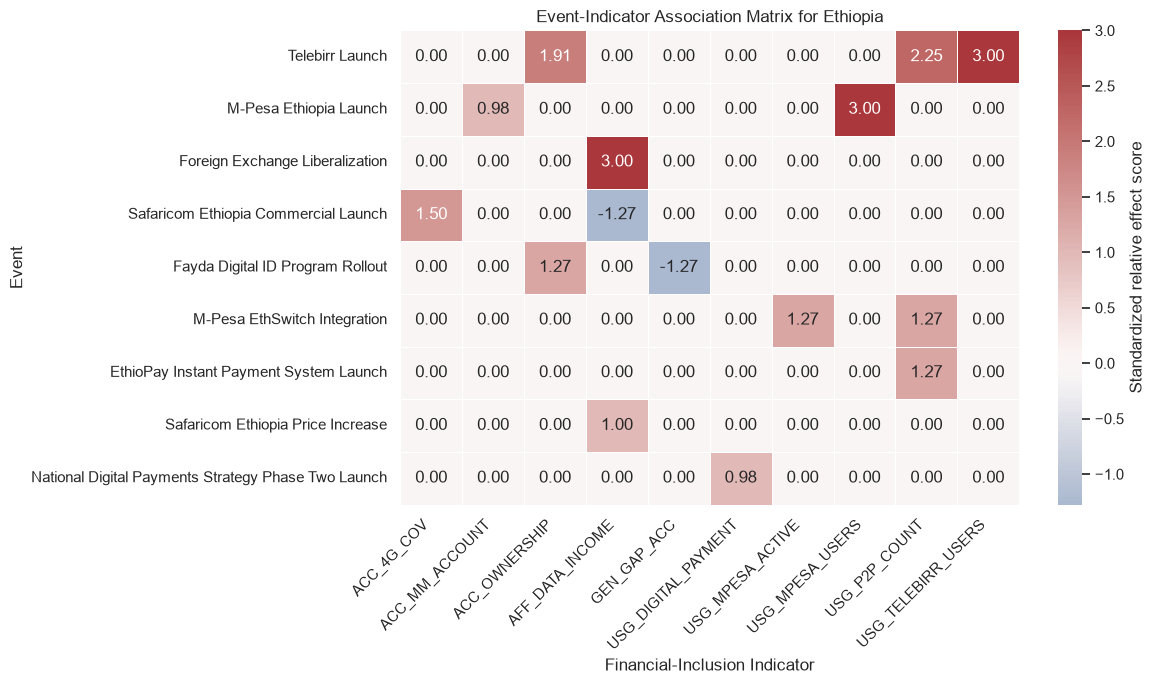

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/event_indicator_association_matrix.png


In [10]:
# Visualize the event-indicator association matrix.

if association_matrix.empty:
    print("The association matrix is empty.")

else:
    figure_width = max(
        12,
        association_matrix.shape[1] * 1.1
    )

    figure_height = max(
        7,
        association_matrix.shape[0] * 0.65
    )

    plt.figure(
        figsize=(figure_width, figure_height)
    )

    sns.heatmap(
        association_matrix,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        linewidths=0.5,
        cbar_kws={
            "label": "Standardized relative effect score"
        }
    )

    plt.title(
        "Event-Indicator Association Matrix for Ethiopia"
    )
    plt.xlabel("Financial-Inclusion Indicator")
    plt.ylabel("Event")
    plt.xticks(
        rotation=45,
        ha="right"
    )
    plt.yticks(rotation=0)
    plt.tight_layout()

    association_figure_path = (
        FIGURE_DIR
        / "event_indicator_association_matrix.png"
    )

    plt.savefig(
        association_figure_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", association_figure_path)

In [11]:
# Model an event effect as a gradual response.
#
# The effect begins at zero when the event occurs and approaches the
# full modeled effect over time. lag_months controls how quickly the
# effect develops.

def gradual_event_effect(
    months_after_event,
    total_effect,
    lag_months
):
    months_after_event = np.asarray(
        months_after_event,
        dtype=float
    )

    result = np.zeros_like(
        months_after_event,
        dtype=float
    )

    active_mask = months_after_event >= 0

    if lag_months <= 0:
        result[active_mask] = total_effect
        return result

    time_constant = max(
        float(lag_months),
        1.0
    )

    result[active_mask] = (
        total_effect
        * (
            1
            - np.exp(
                -months_after_event[active_mask]
                / time_constant
            )
        )
    )

    return result


# Demonstrate the response function.
example_months = np.arange(0, 37)

example_effect = gradual_event_effect(
    months_after_event=example_months,
    total_effect=2.0,
    lag_months=12
)

example_profile = pd.DataFrame({
    "months_after_event": example_months,
    "modeled_effect": example_effect
})

display(example_profile.head(15))

,months_after_event,modeled_effect
0,0,0.000000
1,1,0.159911
2,2,0.307037
3,3,0.442398
4,4,0.566937
5,5,0.681519
6,6,0.786939
7,7,0.883930
8,8,0.973166
9,9,1.055267


In [15]:
# Build a 36-month modeled effect profile for every impact link.

profile_records = []

for _, row in impact_event_model.iterrows():
    months = np.arange(0, 37)

    effects = gradual_event_effect(
        months_after_event=months,
        total_effect=row["effect_score"],
        lag_months=row["lag_months"]
    )

    for month, modeled_effect in zip(
        months,
        effects
    ):
        profile_records.append({
            "impact_link_id": row["record_id"],
            "event_name": row["event_name_resolved"],
            "event_date": row["event_date_resolved"],
            "related_indicator": row["related_indicator"],
            "months_after_event": int(month),
            "modeled_effect": float(modeled_effect),
            "final_effect_score": float(
                row["effect_score"]
            ),
            "lag_months": float(
                row["lag_months"]
            )
        })

event_effect_profiles = pd.DataFrame(
    profile_records
)

profile_path = (
    OUTPUT_DIR
    / "event_effect_profiles_36_months.csv"
)

event_effect_profiles.to_csv(
    profile_path,
    index=False
)

display(event_effect_profiles.head(20))

print("Saved:", profile_path)
print("Rows:", len(event_effect_profiles))

,impact_link_id,event_name,event_date,related_indicator,months_after_event,modeled_effect,final_effect_score,lag_months
0,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,0,0.000000,1.9125,12.0
1,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,1,0.152915,1.9125,12.0
2,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,2,0.293604,1.9125,12.0
3,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,3,0.423044,1.9125,12.0
4,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,4,0.542134,1.9125,12.0
5,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,5,0.651702,1.9125,12.0
6,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,6,0.752510,1.9125,12.0
7,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,7,0.845258,1.9125,12.0
8,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,8,0.930590,1.9125,12.0
9,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,9,1.009099,1.9125,12.0


Saved: /Users/mac/Ethiopia-FI-Interim/data/processed/event_effect_profiles_36_months.csv
Rows: 555


Number of non-zero relationships: 15
Relationships included in the figure: 5


,event_name_resolved,related_indicator,impact_direction,impact_magnitude,effect_score,lag_months
0,Telebirr Launch,USG_TELEBIRR_USERS,increase,high,3.0000,3.0
1,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,3.0000,3.0
2,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,high,3.0000,3.0
3,Telebirr Launch,USG_P2P_COUNT,increase,high,2.2500,6.0
4,Telebirr Launch,ACC_OWNERSHIP,increase,high,1.9125,12.0


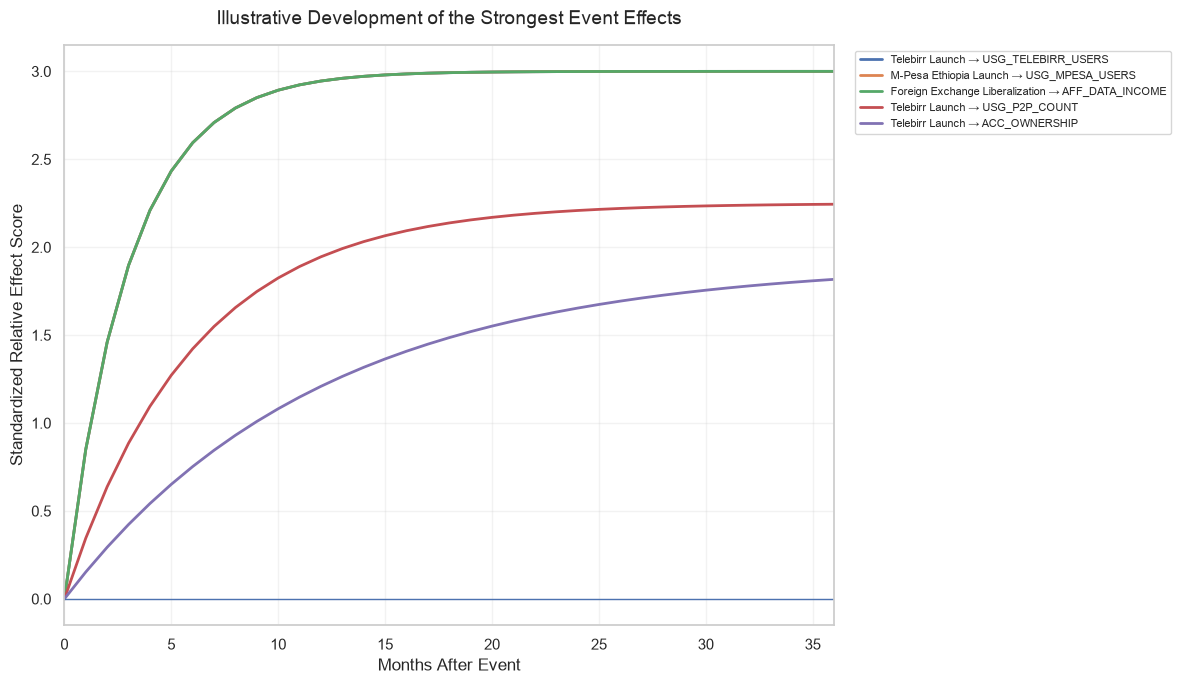

Relationships plotted: 5
Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/event_effect_profiles.png


In [16]:

required_columns = [
    "record_id",
    "event_name_resolved",
    "related_indicator",
    "effect_score",
    "lag_months"
]

missing_columns = [
    column
    for column in required_columns
    if column not in impact_event_model.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

# Remove missing and zero-effect relationships.
non_zero_links = (
    impact_event_model
    .dropna(subset=["effect_score"])
    .copy()
)

non_zero_links = non_zero_links[
    non_zero_links["effect_score"].abs() > 0.0001
].copy()

# Rank relationships by the absolute size of their final effect.
non_zero_links["absolute_effect"] = (
    non_zero_links["effect_score"].abs()
)

top_links = (
    non_zero_links
    .sort_values(
        "absolute_effect",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

print(
    "Number of non-zero relationships:",
    len(non_zero_links)
)

print(
    "Relationships included in the figure:",
    len(top_links)
)

display_columns = [
    "event_name_resolved",
    "related_indicator",
    "impact_direction",
    "impact_magnitude",
    "effect_score",
    "lag_months"
]

display(
    top_links[
        [
            column
            for column in display_columns
            if column in top_links.columns
        ]
    ]
)

if top_links.empty:
    print(
        "No non-zero modeled relationships were available "
        "for visualization."
    )

else:
    plt.figure(figsize=(12, 7))

    plotted_relationships = 0

    for _, row in top_links.iterrows():
        link_profile = (
            event_effect_profiles[
                event_effect_profiles[
                    "impact_link_id"
                ].eq(row["record_id"])
            ]
            .sort_values("months_after_event")
            .copy()
        )

        if link_profile.empty:
            print(
                "No effect profile found for:",
                row["record_id"]
            )
            continue

        relationship_label = (
            f'{row["event_name_resolved"]}'
            f' → {row["related_indicator"]}'
        )

        plt.plot(
            link_profile["months_after_event"],
            link_profile["modeled_effect"],
            linewidth=2,
            label=relationship_label
        )

        plotted_relationships += 1

    plt.axhline(
        y=0,
        linewidth=1
    )

    plt.title(
        "Illustrative Development of the Strongest Event Effects",
        fontsize=14,
        pad=15
    )

    plt.xlabel(
        "Months After Event"
    )

    plt.ylabel(
        "Standardized Relative Effect Score"
    )

    plt.xlim(
        left=0,
        right=36
    )

    plt.grid(
        alpha=0.25
    )

    if plotted_relationships > 0:
        plt.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8
        )

    plt.tight_layout()

    profile_figure_path = (
        FIGURE_DIR
        / "event_effect_profiles.png"
    )

    plt.savefig(
        profile_figure_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Relationships plotted:",
        plotted_relationships
    )

    print(
        "Saved:",
        profile_figure_path
    )

In [18]:
# Historical validation using the limited observations available.

# Global Findex Access observations.
access_validation = pd.DataFrame({
    "year": [2011, 2014, 2017, 2021, 2024],
    "account_ownership_percent": [
        14.0,
        22.0,
        35.0,
        46.0,
        49.0
    ]
})

access_validation["observed_change_pp"] = (
    access_validation[
        "account_ownership_percent"
    ].diff()
)

# Mobile-money account ownership evidence supplied by the project.
mobile_money_validation = pd.DataFrame({
    "year": [2021, 2024],
    "mobile_money_account_percent": [
        4.70,
        9.45
    ]
})

observed_mm_change = (
    mobile_money_validation[
        "mobile_money_account_percent"
    ].iloc[-1]
    - mobile_money_validation[
        "mobile_money_account_percent"
    ].iloc[0]
)

# Telebirr model signal.
telebirr_mask = (
    impact_event_model["event_name_resolved"]
    .astype(str)
    .str.contains(
        "telebirr",
        case=False,
        na=False
    )
)

telebirr_model_signal = (
    impact_event_model.loc[
        telebirr_mask,
        "effect_score"
    ].sum()
)

# Access signal from events dated between 2021 and 2024.
event_dates = pd.to_datetime(
    impact_event_model["event_date_resolved"],
    errors="coerce"
)

access_indicator_mask = (
    impact_event_model["related_indicator"]
    .astype(str)
    .str.contains(
        "ACC_OWNERSHIP",
        case=False,
        na=False
    )
)

period_mask = event_dates.between(
    "2021-01-01",
    "2024-12-31"
)

access_model_signal_2021_2024 = (
    impact_event_model.loc[
        access_indicator_mask & period_mask,
        "effect_score"
    ].sum()
)

validation_summary = pd.DataFrame({
    "validation_item": [
        "Mobile-money account ownership, 2021–2024",
        "Overall account ownership, 2021–2024"
    ],
    "observed_change_pp": [
        observed_mm_change,
        3.0
    ],
    "model_signal": [
        telebirr_model_signal,
        access_model_signal_2021_2024
    ],
    "interpretation": [
        (
            "Mobile-money ownership increased after Telebirr's launch. "
            "The positive model signal is directionally consistent, "
            "but the model does not prove causality."
        ),
        (
            "Account ownership increased only three percentage points. "
            "This suggests that registrations, product launches, and "
            "infrastructure expansion do not translate one-for-one into "
            "new unique adult account owners."
        )
    ]
})

print("Access history")
display(access_validation)

print("\nMobile-money history")
display(mobile_money_validation)

print("\nValidation summary")
display(validation_summary)

Access history


,year,account_ownership_percent,observed_change_pp
0,2011,14.0,NaN
1,2014,22.0,8.0
2,2017,35.0,13.0
3,2021,46.0,11.0
4,2024,49.0,3.0



Mobile-money history


,year,mobile_money_account_percent
0,2021,4.70
1,2024,9.45



Validation summary


,validation_item,observed_change_pp,model_signal,interpretation
0,"Mobile-money account ownership, 2021–2024",4.75,7.1625,Mobile-money ownership increased after Telebir...
1,"Overall account ownership, 2021–2024",3.00,3.1875,Account ownership increased only three percent...


In [19]:
validation_path = (
    OUTPUT_DIR
    / "event_impact_validation.csv"
)

validation_summary.to_csv(
    validation_path,
    index=False
)

print("Saved:", validation_path)

Saved: /Users/mac/Ethiopia-FI-Interim/data/processed/event_impact_validation.csv


In [20]:
model_parameters = {
    "model_name": (
        "Standardized event-indicator association model"
    ),
    "score_interpretation": {
        "positive": (
            "Expected increase or supportive effect"
        ),
        "negative": (
            "Expected decrease or constraining effect"
        ),
        "zero": (
            "Mixed, neutral, or currently unclear effect"
        )
    },
    "direction_map": direction_map,
    "magnitude_map": magnitude_map,
    "evidence_weight_map": evidence_weight_map,
    "confidence_weight_map": confidence_weight_map,
    "temporal_response": {
        "functional_form": (
            "effect * (1 - exp(-months_after_event / lag_months))"
        ),
        "pre_event_effect": 0,
        "combination_rule": (
            "Effects from multiple links are additive"
        ),
        "forecast_horizon_months": 36
    },
    "limitations": [
        (
            "Association scores are relative strengths and are not "
            "direct percentage-point estimates."
        ),
        (
            "Sparse observations prevent reliable causal estimation."
        ),
        (
            "Multiple events may overlap during the same period."
        ),
        (
            "Administrative registrations are not equivalent to "
            "unique active adult users."
        ),
        (
            "Evidence quality and confidence assessments are partly "
            "judgment-based."
        )
    ]
}

parameters_path = (
    MODEL_DIR
    / "event_impact_parameters.json"
)

with open(
    parameters_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_parameters,
        file,
        indent=2
    )

print("Saved:", parameters_path)

Saved: /Users/mac/Ethiopia-FI-Interim/models/event_impact_parameters.json


## Task 3 Methodology and Findings

### Modeling approach

The event-impact model joins each `impact_link` record to its parent event
through `parent_id`. Each relationship is converted into a standardized
relative association score using four components:

1. impact direction;
2. impact magnitude;
3. evidence-basis weight;
4. confidence weight.

Positive scores represent an expected increase or supportive relationship,
while negative scores represent an expected reduction or constraining
relationship. The scores are relative strengths and must not be interpreted
as exact percentage-point effects.

### Temporal response

Event effects are represented using a gradual saturation function. The
modeled effect is zero before the event and develops toward its full score
after the event. The `lag_months` field controls how quickly the effect
develops. Links with no stated lag are treated as immediate.

Effects from multiple events are combined additively. This is a transparent
working assumption rather than a proven causal mechanism.

### Validation observations

Mobile-money account ownership increased from approximately 4.7% in 2021
to 9.45% in 2024, an increase of 4.75 percentage points following the
Telebirr launch period. The positive Telebirr association signal is
directionally consistent with that increase.

However, overall account ownership increased by only three percentage
points between 2021 and 2024. This indicates that mobile-money
registrations and product expansion did not translate one-for-one into new
unique adult account owners. Possible explanations include inactive
accounts, duplicate registrations, substitution between providers, existing
bank customers opening mobile-money accounts, affordability constraints,
and delays before infrastructure improvements affect survey outcomes.

### Main assumptions

- Event-indicator relationships are additive.
- Direction, magnitude, evidence, and confidence codes contain meaningful
  information about relative impact.
- Effects generally develop gradually after an event.
- Events do not influence indicators before their event dates.
- Association scores are not causal estimates or percentage-point forecasts.
- Structural policy and infrastructure effects may persist beyond the
  36-month illustration period.

### Main uncertainties

- Ethiopia has only five national account-ownership survey observations.
- Several Usage indicators contain only one or two observations.
- Multiple major events occurred between the same survey years.
- Administrative registered-user counts are not directly comparable with
  survey-reported adult ownership or active use.
- Comparable-country evidence may not transfer perfectly to Ethiopia.
- Event effects may interact rather than combine independently.

### Task 3 conclusion

The model provides a reproducible event-indicator association framework
that can be incorporated into scenario-based forecasting. It identifies
which events are expected to affect each indicator, the expected direction
and relative strength, and the approximate timing of those effects.
Because the historical data are sparse, the scores should be used as
scenario inputs and sensitivity parameters rather than as definitive
causal estimates.

In [21]:
required_task_3_files = [
    OUTPUT_DIR / "event_impact_link_summary.csv",
    OUTPUT_DIR / "event_indicator_association_matrix.csv",
    OUTPUT_DIR / "event_effect_profiles_36_months.csv",
    OUTPUT_DIR / "event_impact_validation.csv",
    FIGURE_DIR / "event_indicator_association_matrix.png",
    FIGURE_DIR / "event_effect_profiles.png",
    MODEL_DIR / "event_impact_parameters.json"
]

print("TASK 3 OUTPUT CHECK")
print("=" * 60)

all_outputs_found = True

for file_path in required_task_3_files:
    exists = file_path.exists()

    print(
        f"{'PASS' if exists else 'MISSING'}: "
        f"{file_path.relative_to(PROJECT_ROOT)}"
    )

    all_outputs_found = (
        all_outputs_found and exists
    )

print(
    "\nFINAL RESULT:",
    "PASS" if all_outputs_found else "CHECK MISSING FILES"
)

TASK 3 OUTPUT CHECK
PASS: data/processed/event_impact_link_summary.csv
PASS: data/processed/event_indicator_association_matrix.csv
PASS: data/processed/event_effect_profiles_36_months.csv
PASS: data/processed/event_impact_validation.csv
PASS: reports/figures/event_indicator_association_matrix.png
PASS: reports/figures/event_effect_profiles.png
PASS: models/event_impact_parameters.json

FINAL RESULT: PASS
